# 1. CONFIGURAÇÃO DO AMBIENTE E BIBLIOTECAS

In [122]:
# Pandas: Biblioteca padrão para manipulação de dados em tabelas (DataFrames)
import pandas as pd

# NumPy: Biblioteca para computação numérica de alto desempenho e vetorização de matrizes
import numpy as np

# Matplotlib.pyplot: Módulo essencial para plotagem de gráficos e exportação de figuras
import matplotlib.pyplot as plt

# Seaborn: Biblioteca de visualização estatística baseada no Matplotlib
import seaborn as sns

# SHAP: Biblioteca de IA Explicável baseada em Valores de Shapley (Teoria dos Jogos Cooperativos)
import shap

# Gzip: Utilitário para abrir e descompactar os arquivos compactados dos modelos (.gz)
import gzip

# Pickle: Biblioteca para ler e desserializar objetos Python salvos em disco
import pickle

# Copy: Permite realizar cópias profundas em memória, evitando mutações acidentais de objetos
import copy

# OS: Interface com o sistema operacional para gerenciamento de arquivos
import os

# Pathlib.Path: Abordagem orientada a objetos para gerenciar caminhos de diretórios de forma limpa
from pathlib import Path

# Datetime: Módulo para captura de carimbos de tempo (timestamps) e gerenciamento de datas
from datetime import datetime

# Importação de métricas oficiais do Scikit-Learn para validação do desempenho dos modelos
from sklearn.metrics import (
    confusion_matrix,        # Gera a matriz de confusão (TP, FP, TN, FN)
    ConfusionMatrixDisplay, # Plota graficamente a matriz de confusão
    accuracy_score,         # Calcula a taxa de acerto global do classificador
    precision_score,        # Calcula a precisão (relevante para monitorar Falsos Positivos)
    recall_score,           # Calcula o recall (relevante para monitorar Falsos Negativos)
    f1_score,               # Média harmônica balanceada entre precisão e recall
    classification_report   # Tabela textual com o resumo completo de métricas por classe
)

# Warnings: Desativa alertas de depreciação do ecossistema Python para manter o console limpo
import warnings
warnings.filterwarnings("ignore")

# RANDOM_STATE: Semente estável compartilhada para garantir reprodutibilidade matemática exata
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Bibliotecas carregadas e semente de reprodutibilidade configurada com sucesso.")

Bibliotecas carregadas e semente de reprodutibilidade configurada com sucesso.


# 2. DIRETÓRIOS, CARREGAMENTO DOS DADOS DE REDE E MODELOS

In [123]:
# Correção para manter compatibilidade com parâmetros legados de estratégias de amostragem
def get_sampling_strategy(*args, **kwargs):
    return "auto"

# PROJECT_ROOT: Sobe um nível em relação ao diretório de execução para mapear a raiz real do projeto
PROJECT_ROOT = Path.cwd().parent

# Definição dos caminhos absolutos dos subdiretórios de dados, resultados e relatórios do projeto
DATASET_DIR = PROJECT_ROOT / "datasense" / "dataset"
RESULTS_DIR = PROJECT_ROOT / "experiments" / "results"
EVAL_DIR = PROJECT_ROOT / "experiments" / "evaluations"
XAI_DIR = PROJECT_ROOT / "experiments" / "results_xai"

# Criação dinâmica e recursiva das pastas de saída
SHAP_GLOBAL_DIR = XAI_DIR / "shap_global"
SHAP_MICRO_DIR = XAI_DIR / "shap_micro"
FPFN_BINARY_DIR = XAI_DIR / "fpfn_binary"
FPFN_MULTI_DIR = XAI_DIR / "fpfn_multiclass"
FIG_DIR = XAI_DIR / "figures"

for path in [SHAP_GLOBAL_DIR, SHAP_MICRO_DIR, FPFN_BINARY_DIR, FPFN_MULTI_DIR, FIG_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# CARREGAMENTO DO DATASET E RÓTULOS 
print("Carregando dataset de teste Parquet...")
dataset = pd.read_parquet(DATASET_DIR / "datasense_full_test_1sec.parquet")

print("="*60)
print("VERIFICAÇÃO DE DIRETÓRIOS")
print("="*60)
print("Dataset:", DATASET_DIR.exists())
print("Results:", RESULTS_DIR.exists())
print("Evaluations:", EVAL_DIR.exists())

# Extração dos alvos reais: label1 para binário, label2 para as 8 macroclasses do artigo
y_test_binary = dataset["label1"].copy()
y_test_multi = dataset["label2"].copy()

# Remove as colunas de rótulo para isolar estritamente o conjunto de features de tráfego (X_test)
X_test = dataset.drop(columns=["label1", "label2", "label3", "label4"], errors="ignore")
print(f"\nDimensões do X_test original: {X_test.shape}")

# CARREGAMENTO DOS MODELOS
MODEL_PATHS_BINARY = {
    "logistic_regression": RESULTS_DIR / "logistic_regression_full_all" / "pipe.pickle.gz",
    "decision_tree": RESULTS_DIR / "decision_tree_full_all" / "pipe.pickle.gz",
    "random_forest": RESULTS_DIR / "random_forest_full_all" / "pipe.pickle.gz"
}

MODEL_PATHS_MULTI = {
    "logistic_regression_multi": RESULTS_DIR / "logistic_regression_full_grouped" / "pipe.pickle.gz",
    "decision_tree_multi": RESULTS_DIR / "decision_tree_full_grouped" / "pipe.pickle.gz",
    "random_forest_multi": RESULTS_DIR / "random_forest_full_grouped" / "pipe.pickle.gz"
}

MODELS_BINARY = {}
print("\nCarregando modelos binários...")
for name, path in MODEL_PATHS_BINARY.items():
    with gzip.open(path, "rb") as f:
        MODELS_BINARY[name] = pickle.load(f)
    print(f"[OK] {name}")

MODELS_MULTI = {}
print("\nCarregando modelos multiclasses...")
for name, path in MODEL_PATHS_MULTI.items():
    with gzip.open(path, "rb") as f:
        MODELS_MULTI[name] = pickle.load(f)
    print(f"[OK] {name}")

# FEATURE ALIGNMENT: Alinha as colunas de X_test com o preprocessor do pipeline do projeto
ref_model = list(MODELS_MULTI.values())[0] if len(MODELS_MULTI) > 0 else list(MODELS_BINARY.values())[0]
if hasattr(ref_model, "named_steps") and "preprocessor" in ref_model.named_steps:
    try:
        expected_features = ref_model.named_steps["preprocessor"].feature_names_in_
    except:
        expected_features = X_test.columns
else:
    expected_features = X_test.columns

X_test = X_test.reindex(columns=expected_features, fill_value=0)
print(f"\nDataset alinhado com os pipelines. Dimensão final: {X_test.shape}")

# Carrega o arquivo CSV de importância de características padrão para checagem
feature_importance_df = pd.read_csv(EVAL_DIR / "feature_importances.csv")
print("\nFeature Importance carregado com sucesso.")

Carregando dataset de teste Parquet...
VERIFICAÇÃO DE DIRETÓRIOS
Dataset: True
Results: True
Evaluations: True

Dimensões do X_test original: (56798, 107)

Carregando modelos binários...
[OK] logistic_regression
[OK] decision_tree
[OK] random_forest

Carregando modelos multiclasses...
[OK] logistic_regression_multi
[OK] decision_tree_multi
[OK] random_forest_multi

Dataset alinhado com os pipelines. Dimensão final: (56798, 107)

Feature Importance carregado com sucesso.


# 3. FUNÇÕES AUXILIARES DO MOTOR SHAP

In [124]:
# Separa o pré-processador do classificador final contidos no pipeline do Scikit-Learn
def split_pipeline(model):
    if hasattr(model, "named_steps"):
        return model[:-1], model[-1]
    return None, model


# Função para extrair TODAS as colunas pós-pipeline de forma alinhada
def get_valid_features(model):
    try:
        pre = model[:-1]
        features = list(pre.get_feature_names_out())
    except:
        features = list(X_test.columns)
    return features


# Função unificada de cálculo SHAP adaptável por família de modelo
def get_shap(model, X_sample, name):
    pre, final_model = split_pipeline(model)
    X_trans = pre.transform(X_sample) if pre is not None else X_sample
    X_mapped_array = X_trans.values if isinstance(X_trans, pd.DataFrame) else X_trans

    if "tree" in name or "forest" in name:
        explainer = shap.TreeExplainer(final_model)
        values = explainer.shap_values(X_mapped_array)
        return values, X_mapped_array
    elif "logistic" in name:
        explainer = shap.LinearExplainer(final_model, X_mapped_array)
        values = explainer.shap_values(X_mapped_array)
        return values, X_mapped_array
    else:
        explainer = shap.Explainer(final_model, X_mapped_array)
        shap_values_obj = explainer(X_mapped_array)
        return shap_values_obj.values, X_mapped_array


# Função corretora para sincronizar as dimensões do SHAP Multiclasse no formato (samples, classes, features)
def normalize_multiclass_dimensions(values, n_features, n_classes):
    values = np.array(values)
    if values.ndim == 3:
        if values.shape[1] == n_features:
            values = np.transpose(values, (0, 2, 1))
        elif values.shape[0] == n_classes:
            values = np.transpose(values, (1, 0, 2))
    return values


# Função para reduzir matrizes SHAP 2D ou 3D calculando a média absoluta por coluna
def reduce_shap(values):
    values = np.array(values)
    if isinstance(values, list):
        values = values[1]
    if values.ndim == 3:
        values = np.mean(np.abs(values), axis=(0, 2))
    elif values.ndim == 2:
        values = np.mean(np.abs(values), axis=0)
    return values

In [125]:
def validate_shap_rigor(model, X_sample, name):
    """
    Realiza teste de aditividade e monitora fidelidade das explicações SHAP.
    Esta função garante que o modelo atenda aos axiomas de Shapley antes da análise global.
    """
    pre, final_model = split_pipeline(model)
    X_trans = pre.transform(X_sample) if pre is not None else X_sample
    
    # Converte para array NumPy para evitar TypeError no KernelExplainer
    X_arr = np.array(X_trans)
    
    # Identificação da função de predição (Priorizando probabilidades para maior precisão analítica)
    predict_func = getattr(final_model, "predict_proba", final_model.predict)
    
    # Configuração do Explainer com base na família do modelo
    if "tree" in name or "forest" in name:
        explainer = shap.TreeExplainer(final_model)
        shap_values = explainer.shap_values(X_arr)
        expected_value = explainer.expected_value
    else:
        # Nota acadêmica: Uso de KernelExplainer para modelos lineares/genéricos (KernelSHAP)
        background = shap.sample(X_arr, 50)
        explainer = shap.KernelExplainer(predict_func, background)
        shap_values = explainer.shap_values(X_arr)
        expected_value = explainer.expected_value

    # Validação de Aditividade (Axioma da Eficiência)
    # A soma das contribuições (SHAP values) + Valor Esperado deve reconstruir a predição
    if isinstance(shap_values, list): # Caso de modelos multiclasse
        sum_shap = np.sum(shap_values[0], axis=1) + expected_value[0]
        model_pred = predict_func(X_arr)[:, 0] 
    else:
        # Caso de modelos binários ou regressores
        sum_shap = np.sum(shap_values, axis=1) + expected_value
        model_pred = predict_func(X_arr)
        
    # Cálculo do Erro Médio de Aditividade
    diff = np.abs(sum_shap - model_pred).mean()
    print(f"[{name}] Erro Médio de Aditividade: {diff:.6f}")
    
    return diff < 1e-4

# --- EXECUÇÃO DA VALIDAÇÃO ---
print("="*60)
print("INICIANDO VALIDAÇÃO DE RIGOR ACADÊMICO")
print("="*60)

# 1. Validação dos modelos binários
print("\nValidando modelos binários:")
for name, model in MODELS_BINARY.items():
    validate_shap_rigor(model, X_test.head(300), name)

# 2. Validação dos modelos multiclasse
print("\nValidando modelos multiclasse:")
for name, model in MODELS_MULTI.items():
    validate_shap_rigor(model, X_test.head(300), name)

INICIANDO VALIDAÇÃO DE RIGOR ACADÊMICO

Validando modelos binários:


  0%|          | 0/300 [00:00<?, ?it/s]

[logistic_regression] Erro Médio de Aditividade: 0.000000
[decision_tree] Erro Médio de Aditividade: 0.000000
[random_forest] Erro Médio de Aditividade: 0.000000

Validando modelos multiclasse:


  0%|          | 0/300 [00:00<?, ?it/s]

[logistic_regression_multi] Erro Médio de Aditividade: 0.000000
[decision_tree_multi] Erro Médio de Aditividade: 0.000000
[random_forest_multi] Erro Médio de Aditividade: 0.000000


# 4. SHAP GLOBAL BINÁRIO E MULTICLASSE MACRO/MICRO (EXPLICANDO ACERTOS - RESPONDENDO À RQ3)

In [126]:
# Retira uma amostra aleatória estável de 300 registros do dataset para rodar o lote SHAP
batch_sample = X_test.sample(300, random_state=42)
TOP_N = 15

# --------------------------------------------------------------------------
# PART A: SHAP GLOBAL BINÁRIO
# --------------------------------------------------------------------------
print("="*80)
print("[PROCESSO] EXTRAINDO SHAP GLOBAL BINÁRIO")
print("="*80)

for name, model in MODELS_BINARY.items():
    features = get_valid_features(model)
    values, _ = get_shap(model, batch_sample, name)
    global_shap = reduce_shap(values)
    
    aligned_len = min(len(features), global_shap.shape[0])
    
    df_bin = pd.DataFrame({
        "feature": features[:aligned_len],
        "importance": global_shap[:aligned_len]
    })
    
    # FILTRAÇÃO BLINDADA: Remove qualquer atributo contendo as palavras "device" ou "label"
    df_bin = df_bin[~df_bin["feature"].str.contains("device|label", case=False)]
    
    # Salva o arquivo CSV limpo
    df_bin.sort_values("importance", ascending=False).to_csv(
        SHAP_GLOBAL_DIR / f"{name}_binary_global.csv", index=False
    )

# --------------------------------------------------------------------------
# PART B: SHAP MULTICLASSE (MACRO GLOBAL E MICRO POR CLASSE)
# --------------------------------------------------------------------------
print("\n" + "="*80)
print("[PROCESSO] EXTRAINDO SHAP MULTICLASSE MACRO E MICRO (8 CLASSES)")
print("="*80)

for name, model in MODELS_MULTI.items():
    pre, final_model = split_pipeline(model)
    classes = final_model.classes_
    features = get_valid_features(model)
    
    n_classes = len(classes)
    n_features = len(features)

    raw_shap, _ = get_shap(model, batch_sample, name)
    shap_cube = normalize_multiclass_dimensions(raw_shap, n_features, n_classes)
    
    # --- 1. SHAP MACRO GLOBAL ---
    macro_importance = np.mean(np.abs(shap_cube), axis=(0, 1))
    aligned_len = min(len(features), macro_importance.shape[0])
    
    df_macro = pd.DataFrame({
        "feature": features[:aligned_len],
        "importance_macro": macro_importance[:aligned_len]
    })
    df_macro = df_macro[~df_macro["feature"].str.contains("device|label", case=False)]
    df_macro.sort_values("importance_macro", ascending=False).to_csv(
        SHAP_GLOBAL_DIR / f"{name}_multiclass_macro.csv", index=False
    )
    
    # --- 2. SHAP MICRO POR CLASSE ---
    for class_idx, cls_name in enumerate(classes):
        class_slice = shap_cube[:, class_idx, :]
        micro_importance = np.mean(np.abs(class_slice), axis=0)
        
        df_micro = pd.DataFrame({
            "feature": features[:aligned_len],
            "importance_micro": micro_importance[:aligned_len]
        })
        df_micro = df_micro[~df_micro["feature"].str.contains("device|label", case=False)]
        df_micro.sort_values("importance_micro", ascending=False).to_csv(
            SHAP_MICRO_DIR / f"{name}_{cls_name}_micro.csv", index=False
        )

print("\n[SUCESSO] Planilhas SHAP salvas e higienizadas de atributos 'device/label'.")

[PROCESSO] EXTRAINDO SHAP GLOBAL BINÁRIO

[PROCESSO] EXTRAINDO SHAP MULTICLASSE MACRO E MICRO (8 CLASSES)

[SUCESSO] Planilhas SHAP salvas e higienizadas de atributos 'device/label'.


# 5. EXTRAÇÃO DO QUANTITATIVO PURO DE ERROS E ACERTOS (TP, FP, FN)

In [127]:
# ==========================================================================
# PART A: QUANTITATIVO BINÁRIO GLOBAL
# ==========================================================================
print("="*80)
print("EXTRAÇÃO QUANTITATIVA GLOBAL - MODELOS BINÁRIOS")
print("="*80)

binary_metrics_list = []

for name, model in MODELS_BINARY.items():
    pred = model.predict(X_test)
    df_eval = pd.DataFrame({"real": y_test_binary.values, "pred": pred})
    
    TP = ((df_eval.real != "benign") & (df_eval.pred != "benign")).sum()
    FP = ((df_eval.real == "benign") & (df_eval.pred != "benign")).sum()
    FN = ((df_eval.real != "benign") & (df_eval.pred == "benign")).sum()
    
    binary_metrics_list.append({
        "Modelo": name.upper(),
        "True Positives (TP)": TP,
        "False Positives (FP)": FP,
        "False Negatives (FN)": FN
    })

df_binary_results = pd.DataFrame(binary_metrics_list)
display(df_binary_results)
df_binary_results.to_csv(FPFN_BINARY_DIR / "quantitativo_binary_global.csv", index=False)


# ==========================================================================
# PART B: QUANTITATIVO MULTICLASSE MICRO (POR CLASSE - 8 CLASSES)
# ==========================================================================
print("\n" + "="*80)
print("EXTRAÇÃO QUANTITATIVA MICRO POR CLASSE - MODELOS MULTICLASSE")
print("="*80)

for name, model in MODELS_MULTI.items():
    print(f"\n[MODELO MULTICLASSE]: {name.upper()}")
    classes = model[-1].classes_
    pred_multi = model.predict(X_test)
    
    # DataFrame de Erro alinhado diretamente com as 8 classes do label2
    df_eval_multi = pd.DataFrame({
        "real": y_test_multi.values,
        "pred": pred_multi
    })
    
    class_metrics_list = []
    for cls_name in classes:
        TP = ((df_eval_multi.real == cls_name) & (df_eval_multi.pred == cls_name)).sum()
        FP = ((df_eval_multi.real != cls_name) & (df_eval_multi.pred == cls_name)).sum()
        FN = ((df_eval_multi.real == cls_name) & (df_eval_multi.pred != cls_name)).sum()
        
        class_metrics_list.append({
            "Classe Alvo": cls_name,
            "True Positives (TP)": TP,
            "False Positives (FP)": FP,
            "False Negatives (FN)": FN
        })
        
    df_multi_results = pd.DataFrame(class_metrics_list)
    display(df_multi_results)
    df_multi_results.to_csv(FPFN_MULTI_DIR / f"quantitativo_{name}_micro.csv", index=False)

EXTRAÇÃO QUANTITATIVA GLOBAL - MODELOS BINÁRIOS


,Modelo,True Positives (TP),False Positives (FP),False Negatives (FN)
0,LOGISTIC_REGRESSION,20547,17888,2051
1,DECISION_TREE,20184,4305,2414
2,RANDOM_FOREST,20527,7183,2071



EXTRAÇÃO QUANTITATIVA MICRO POR CLASSE - MODELOS MULTICLASSE

[MODELO MULTICLASSE]: LOGISTIC_REGRESSION_MULTI


,Classe Alvo,True Positives (TP),False Positives (FP),False Negatives (FN)
0,benign,27309,3469,6891
1,bruteforce,329,2641,136
2,ddos,1979,1492,2522
3,dos,2598,1766,1984
4,malware,1421,526,467
5,mitm,1236,3276,782
6,recon,5849,1145,2596
7,web,698,1064,1



[MODELO MULTICLASSE]: DECISION_TREE_MULTI


,Classe Alvo,True Positives (TP),False Positives (FP),False Negatives (FN)
0,benign,30717,2420,3483
1,bruteforce,376,1877,89
2,ddos,3962,154,539
3,dos,4236,129,346
4,malware,1691,452,197
5,mitm,1762,331,256
6,recon,6526,438,1919
7,web,696,1031,3



[MODELO MULTICLASSE]: RANDOM_FOREST_MULTI


,Classe Alvo,True Positives (TP),False Positives (FP),False Negatives (FN)
0,benign,30702,2464,3498
1,bruteforce,399,2002,66
2,ddos,3827,55,674
3,dos,4230,136,352
4,malware,1719,340,169
5,mitm,1783,479,235
6,recon,6455,445,1990
7,web,698,1064,1


# 6. COMPILAÇÃO GRÁFICA DAS IMPORTÂNCIAS SHAP (DPI=300)

In [128]:
print("[ROTINA VISUAL] Processando arquivos de dados para gerar gráficos do artigo...")

# Garante o mapeamento autônomo dos caminhos caso ocorra perda de variáveis na memória do Kernel
PROJECT_ROOT = Path.cwd().parent
XAI_DIR = PROJECT_ROOT / "experiments" / "results_xai"
SHAP_GLOBAL_DIR = XAI_DIR / "shap_global"
FIG_DIR = XAI_DIR / "figures"

TOP_N = 15

# Varre estritamente a pasta de resultados SHAP para gerar os gráficos de barras horizontais limpos
for csv_file_path in SHAP_GLOBAL_DIR.glob("*.csv"):
    chart_data_df = pd.read_csv(csv_file_path).head(TOP_N)
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Detecta automaticamente se a coluna se chama importância binária ou macro
    target_importance_col = "importance" if "importance" in chart_data_df.columns else "importance_macro"
    
    ax.barh(
        chart_data_df["feature"].iloc[::-1], 
        chart_data_df[target_importance_col].iloc[::-1], 
        color="#1f77b4", 
        edgecolor="none"
    )
    
    ax.set_xlabel("Mean |SHAP Value| (Impacto Médio na Saída do Modelo)", fontsize=11, fontweight="bold")
    ax.set_ylabel("Atributos de Fluxo de Rede (Features)", fontsize=11, fontweight="bold")
    ax.set_title(f"Importância de Atributos - {csv_file_path.stem.replace('_', ' ').upper()}", fontsize=12, fontweight="bold", pad=15)
    ax.grid(axis="x", linestyle="--", alpha=0.5)
    
    plt.tight_layout()
    # Salva as figuras em altíssima qualidade (300 DPI) livres de atributos irrelevantes
    plt.savefig(FIG_DIR / f"plot_{csv_file_path.stem}.png", dpi=300, bbox_inches="tight")
    plt.close()

print(f"\n[SUCESSO] Todo o pipeline foi atualizado. Gráficos gerados com sucesso em: {FIG_DIR}")

[ROTINA VISUAL] Processando arquivos de dados para gerar gráficos do artigo...

[SUCESSO] Todo o pipeline foi atualizado. Gráficos gerados com sucesso em: c:\Users\bruno.lima\Documents\Projeto IIoT XAI\iiot_threat_detec-main\experiments\results_xai\figures


# 8. DIAGNÓSTICO FORENSE FN FP

In [129]:
# Caminhos
FPFN_MULTI_DIR = Path.cwd().parent / "experiments" / "results_xai" / "fpfn_multiclass"
FIG_ERRORS_DIR = Path.cwd().parent / "experiments" / "results_xai" / "figures_errors"
FIG_ERRORS_DIR.mkdir(parents=True, exist_ok=True)

TOP_K_DISPLAY = 5

print("="*80)
print("GERANDO DIAGNÓSTICO FORENSE E GRÁFICOS DE DRIVERS DE ERRO")
print("="*80)

diagnostic_files = list(FPFN_MULTI_DIR.glob("*_error_diagnostic.csv"))

for diagnostic_file in diagnostic_files:
    df_diag = pd.read_csv(diagnostic_file)
    
    parts = diagnostic_file.stem.split('_')
    model_name = "_".join(parts[:-3])
    class_name = parts[-3]
    
    # Filtra ruído
    df_diag = df_diag[~df_diag["feature"].str.contains("device|label", case=False)]
    
    # Processa FP e FN
    for error_type in ["FP", "FN"]:
        col_name = f"{error_type}_SHAP_Dir"
        # Seleciona os 5 maiores impactos absolutos
        df_top = df_diag.assign(abs_val=df_diag[col_name].abs()).sort_values("abs_val", ascending=False).head(TOP_K_DISPLAY)
        
        # Gerar Gráfico
        plt.figure(figsize=(8, 4))
        plt.barh(df_top["feature"].iloc[::-1], df_top[col_name].iloc[::-1], color="salmon" if error_type=="FP" else "skyblue")
        plt.title(f"Drivers de {error_type} - Modelo: {model_name.upper()} | Classe: {class_name.upper()}", fontsize=10, fontweight="bold")
        plt.xlabel("SHAP Impact")
        plt.tight_layout()
        
        # Salva o gráfico
        plt.savefig(FIG_ERRORS_DIR / f"{model_name}_{class_name}_{error_type}_drivers.png", dpi=300)
        plt.close()
        
    print(f"Relatório e gráficos gerados para: {model_name} | {class_name}")

print(f"\n[SUCESSO] Todos os gráficos foram salvos em: {FIG_ERRORS_DIR}")

GERANDO DIAGNÓSTICO FORENSE E GRÁFICOS DE DRIVERS DE ERRO
Relatório e gráficos gerados para: decision_tree_multi | benign
Relatório e gráficos gerados para: decision_tree_multi | bruteforce
Relatório e gráficos gerados para: decision_tree_multi | ddos
Relatório e gráficos gerados para: decision_tree_multi | dos
Relatório e gráficos gerados para: decision_tree_multi | malware
Relatório e gráficos gerados para: decision_tree_multi | mitm
Relatório e gráficos gerados para: decision_tree_multi | recon
Relatório e gráficos gerados para: logistic_regression_multi | benign
Relatório e gráficos gerados para: logistic_regression_multi | bruteforce
Relatório e gráficos gerados para: logistic_regression_multi | ddos
Relatório e gráficos gerados para: logistic_regression_multi | dos
Relatório e gráficos gerados para: logistic_regression_multi | malware
Relatório e gráficos gerados para: logistic_regression_multi | mitm
Relatório e gráficos gerados para: logistic_regression_multi | recon
Relatório 

RELATÓRIO EXECUTIVO: SHAP GLOBAL + PERFORMANCE + FORENSE

[EXIBINDO SHAP GLOBAL DOS MODELOS]

Dados para: DECISION TREE BINARY GLOBAL


,Feature,SHAP Value
9,network_ips_dst_count,0.0018
8,network_time-delta_avg,0.0018
7,network_ttl_min,0.0019
6,network_tcp-flags_min,0.0019
5,network_tcp-flags-syn_count,0.0022
4,network_packet-size_max,0.0022
3,network_window-size_min,0.0034
2,network_packets_dst_count,0.0043
1,network_tcp-flags_std_deviation,0.0043
0,network_ports_all_count,0.0081


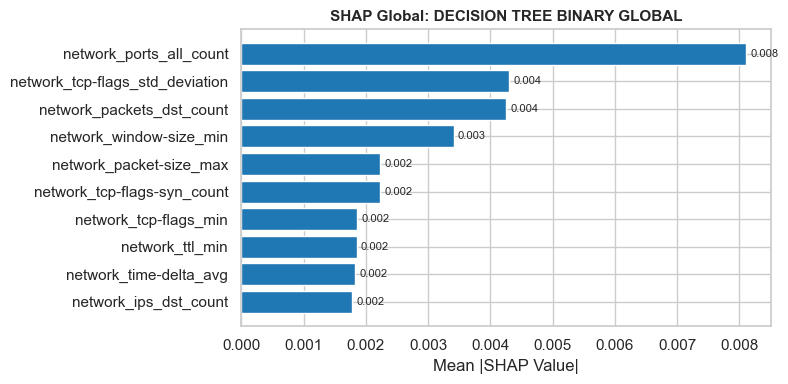


Dados para: DECISION TREE MULTI MULTICLASS MACRO


,Feature,SHAP Value
9,network_macs_dst_count,0.0103
8,network_window-size_min,0.0112
7,network_ips_dst_count,0.0117
6,network_ip-length_min,0.0128
5,network_window-size_std_deviation,0.0141
4,network_ip-length_max,0.0142
3,network_ttl_min,0.0202
2,network_tcp-flags_std_deviation,0.0300
1,network_packet-size_min,0.0363
0,network_packets_dst_count,0.0607


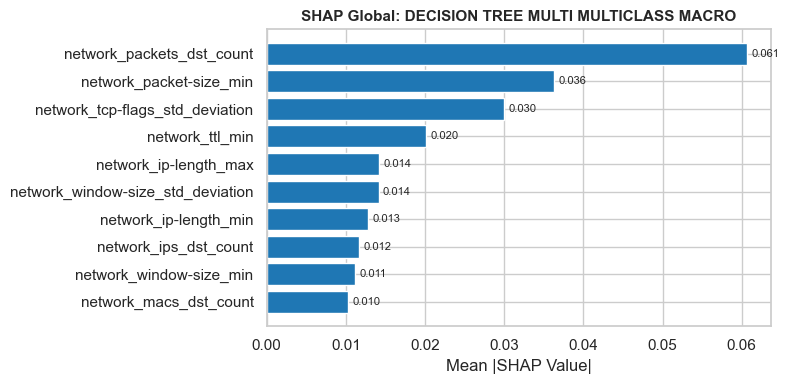


Dados para: LOGISTIC REGRESSION BINARY GLOBAL


,Feature,SHAP Value
9,network_interval-packets,0.6392
8,network_tcp-flags-psh_count,0.6792
7,network_protocols_src_has_mqtt,0.7155
6,network_tcp-flags-syn_count,0.7703
5,network_packet-size_min,0.8021
4,network_packet-size_std_deviation,0.9078
3,network_mss_min,1.1585
2,network_window-size_min,1.2969
1,network_ip-flags_std_deviation,1.6526
0,network_ports_src_count,2.0809


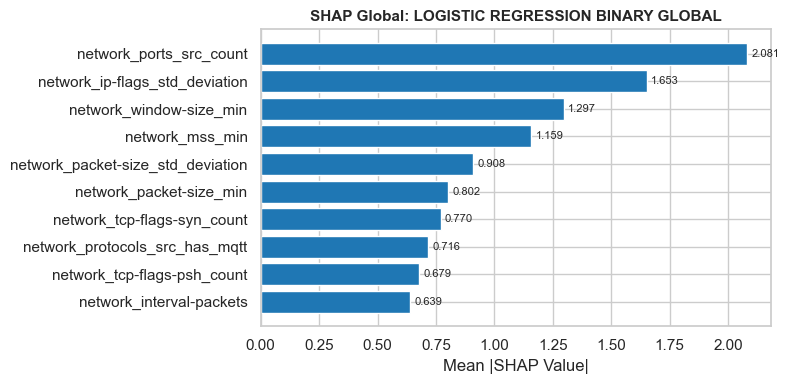


Dados para: LOGISTIC REGRESSION MULTI MULTICLASS MACRO


,Feature,SHAP Value
9,network_window-size_min,0.4659
8,network_fragmented-packets,0.5018
7,network_packet-size_std_deviation,0.5069
6,network_tcp-flags-psh_count,0.5189
5,network_mss_min,0.5321
4,network_packet-size_min,0.5418
3,network_ports_dst_has_23,0.5548
2,network_tcp-flags-syn_count,0.6065
1,network_protocols_dst_has_mqtt,0.6214
0,network_ports_src_count,2.0482


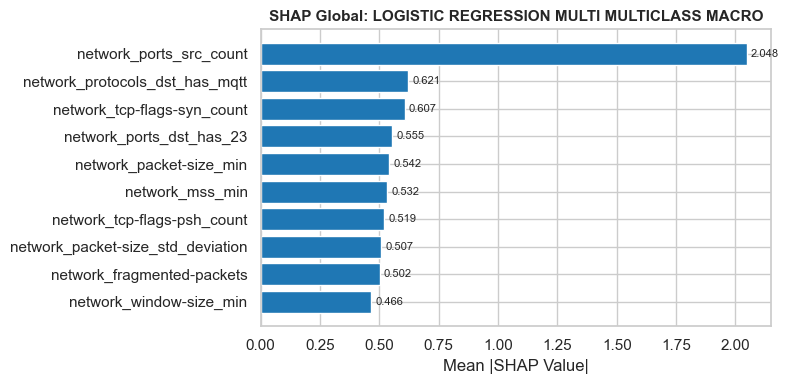


Dados para: RANDOM FOREST BINARY GLOBAL


,Feature,SHAP Value
9,network_packets_all_count,0.0012
8,network_tcp-flags_std_deviation,0.0012
7,network_fragmented-packets,0.0013
6,network_packet-size_avg,0.0015
5,network_packets_dst_count,0.0015
4,network_ports_all_count,0.0016
3,network_window-size_min,0.0017
2,network_tcp-flags-syn_count,0.0019
1,network_tcp-flags-fin_count,0.0029
0,network_ports_src_count,0.0032


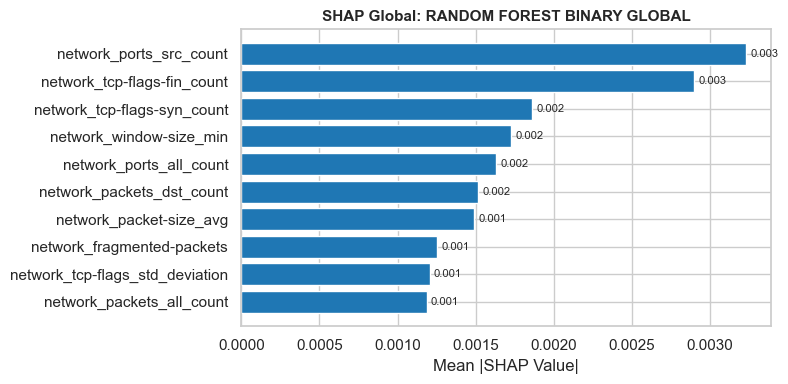


Dados para: RANDOM FOREST MULTI MULTICLASS MACRO


,Feature,SHAP Value
9,network_macs_all_count,0.0069
8,network_time-delta_avg,0.0071
7,network_window-size_std_deviation,0.0071
6,network_time-delta_std_deviation,0.0073
5,network_window-size_min,0.0078
4,network_ttl_min,0.0086
3,network_ports_all_count,0.0105
2,network_packets_all_count,0.0186
1,network_packets_dst_count,0.0237
0,network_packet-size_min,0.0242


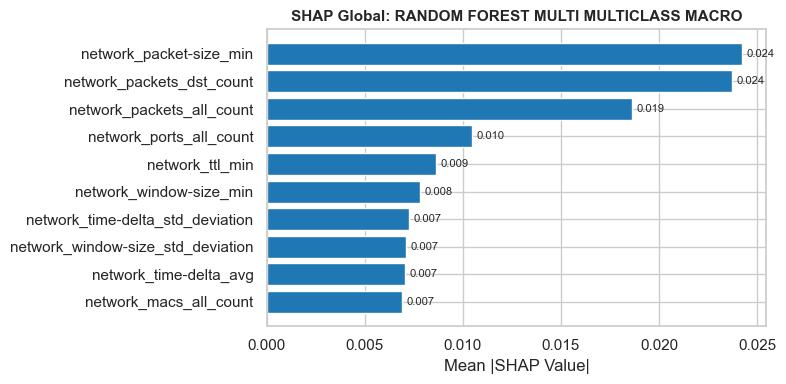


[TABELA MESTRA DE PERFORMANCE]


,Classe Alvo,True Positives (TP),False Positives (FP),False Negatives (FN),Modelo
0,benign,30717,2420,3483,decision_tree_multi
1,bruteforce,376,1877,89,decision_tree_multi
2,ddos,3962,154,539,decision_tree_multi
3,dos,4236,129,346,decision_tree_multi
4,malware,1691,452,197,decision_tree_multi
5,mitm,1762,331,256,decision_tree_multi
6,recon,6526,438,1919,decision_tree_multi
7,web,696,1031,3,decision_tree_multi
8,benign,27309,3469,6891,logistic_regression_multi
9,bruteforce,329,2641,136,logistic_regression_multi


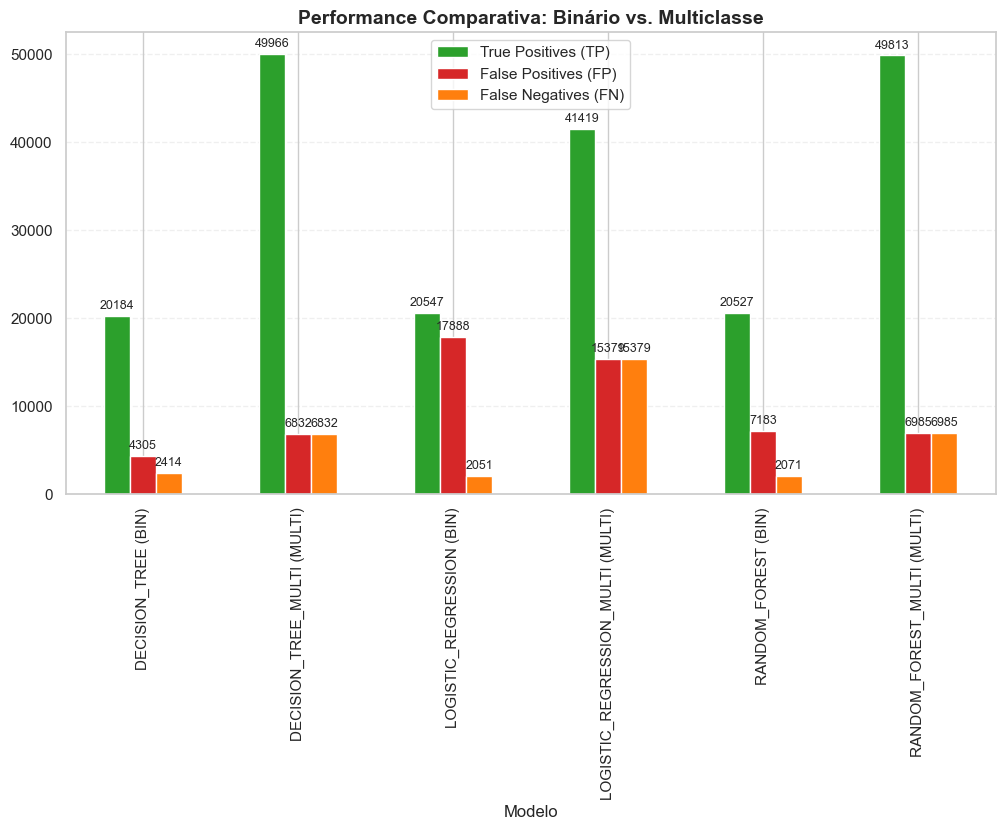


[RANKING DOS SUPER-DRIVERS DE ERRO - GLOBAL]

Top 5 Causadores de FPs:


,feature,FP_SHAP_Dir,FN_SHAP_Dir,Classes_Afetadas
12,network_packet-size_min,0.019148,0.016599,"dos, recon, malware"
7,network_ip-flags_avg,0.009820,0.005887,"recon, malware, ddos"
1,network_fragmented-packets,0.008063,0.005724,"bruteforce, recon, ddos"
11,network_mss_std_deviation,0.006498,0.012054,"benign, bruteforce, mitm"
0,network_fragmentation-score,0.006246,0.004029,"benign, ddos, recon"



Top 5 Causadores de FNs:


,feature,FP_SHAP_Dir,FN_SHAP_Dir,Classes_Afetadas
12,network_packet-size_min,0.019148,0.016599,"mitm, malware, benign"
11,network_mss_std_deviation,0.006498,0.012054,"mitm, dos, recon"
8,network_ip-flags_min,0.003305,0.011128,"ddos, dos, benign"
10,network_mss_min,0.004421,0.009807,"malware, dos, benign"
9,network_ip-flags_std_deviation,0.004318,0.007280,"recon, dos, mitm"


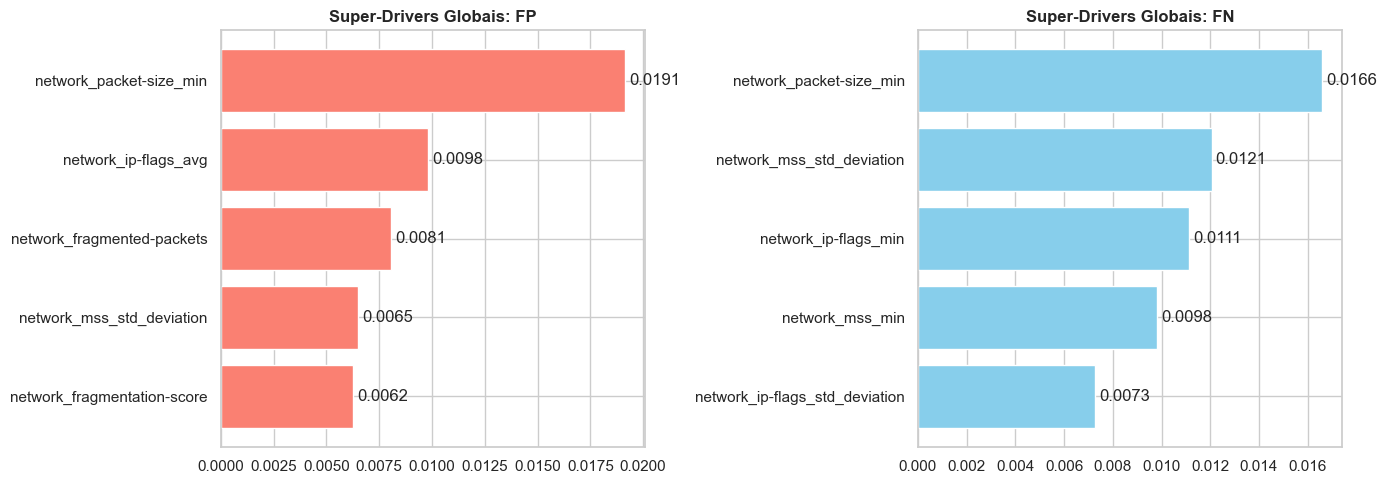

In [130]:
# Definições de diretórios
XAI_DIR = Path.cwd().parent / "experiments" / "results_xai"
SHAP_GLOBAL_DIR = XAI_DIR / "shap_global"
FPFN_BINARY_DIR = XAI_DIR / "fpfn_binary"
FPFN_MULTI_DIR = XAI_DIR / "fpfn_multiclass"
FIG_ERRORS_DIR = XAI_DIR / "figures_errors"

print("="*80)
print("RELATÓRIO EXECUTIVO: SHAP GLOBAL + PERFORMANCE + FORENSE")
print("="*80)

# --- 1. PLOT SHAP GLOBAL (BINÁRIO E MULTICLASSE) ---
print("\n[EXIBINDO SHAP GLOBAL DOS MODELOS]")
for csv_file in SHAP_GLOBAL_DIR.glob("*.csv"):
    df_raw = pd.read_csv(csv_file).head(10)
    col = "importance" if "importance" in df_raw.columns else "importance_macro"
    
    # 1. Prepara os dados: Seleciona colunas e inverte a ordem para o padrão visual (maior no topo)
    # .iloc[::-1] inverte o dataframe para que o maior valor fique no topo no gráfico e na tabela
    df_plot = df_raw[["feature", col]].iloc[::-1].copy()
    df_plot.columns = ["Feature", "SHAP Value"]
    
    # Exibe a tabela com os MESMOS valores que aparecerão no gráfico
    print(f"\nDados para: {csv_file.stem.replace('_', ' ').upper()}")
    display(df_plot.style.format({"SHAP Value": "{:.4f}"}))
    
    # Gera o gráfico
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.barh(df_plot["Feature"], df_plot["SHAP Value"], color="#1f77b4")
    
    # Formatação do rótulo para bater com a precisão da tabela (3 casas como no gráfico original)
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
    
    plt.title(f"SHAP Global: {csv_file.stem.replace('_', ' ').upper()}", fontsize=11, fontweight="bold")
    plt.xlabel("Mean |SHAP Value|")
    plt.tight_layout()
    plt.show()

# --- 2. RESUMO QUANTITATIVO (Tabela Mestra) ---
summary_data = [pd.read_csv(f).assign(Modelo=f.stem.replace("quantitativo_", "").replace("_final", "")) 
                for f in FPFN_MULTI_DIR.glob("quantitativo_*_final.csv")]
df_summary = pd.concat(summary_data, ignore_index=True)
print("\n[TABELA MESTRA DE PERFORMANCE]")
display(df_summary)

# --- 3. GRÁFICO COMPARATIVO DE PERFORMANCE (BIN + MULTI) ---
df_bin = pd.read_csv(FPFN_BINARY_DIR / "quantitativo_binary_global.csv").assign(Modelo=lambda x: x["Modelo"] + " (BIN)")
all_summary = [df_bin] + [pd.read_csv(f).assign(Modelo=f.stem.replace("quantitativo_", "").replace("_final", "").upper() + " (MULTI)") 
                          for f in FPFN_MULTI_DIR.glob("quantitativo_*_final.csv")]
df_total = pd.concat(all_summary, ignore_index=True)

df_plot = df_total.groupby("Modelo")[["True Positives (TP)", "False Positives (FP)", "False Negatives (FN)"]].sum()
ax = df_plot.plot(kind='bar', figsize=(12, 6), color=['#2ca02c', '#d62728', '#ff7f0e'])
for container in ax.containers: ax.bar_label(container, fmt='%d', padding=3, fontsize=9)
plt.title("Performance Comparativa: Binário vs. Multiclasse", fontsize=14, fontweight="bold")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

# --- 4. RANKING DE SUPER-DRIVERS + RELAÇÃO CLASSE-FEATURE ---
all_drivers = []
for diag_file in FPFN_MULTI_DIR.glob("*_error_diagnostic.csv"):
    df = pd.read_csv(diag_file)
    df["Classe_Relacionada"] = diag_file.stem.split('_')[-3]
    all_drivers.append(df[~df["feature"].str.contains("device|label", case=False)])

df_all_drivers = pd.concat(all_drivers, ignore_index=True)
df_ranking = df_all_drivers.groupby("feature")[["FP_SHAP_Dir", "FN_SHAP_Dir"]].apply(lambda x: x.abs().mean()).reset_index()

def get_related_classes(feature, col):
    return ", ".join(df_all_drivers[df_all_drivers["feature"] == feature].sort_values(col, ascending=False).head(3)["Classe_Relacionada"].unique())

print("\n[RANKING DOS SUPER-DRIVERS DE ERRO - GLOBAL]")
for col in ["FP_SHAP_Dir", "FN_SHAP_Dir"]:
    df_top = df_ranking.sort_values(col, ascending=False).head(5)
    df_top["Classes_Afetadas"] = df_top["feature"].apply(lambda x: get_related_classes(x, col))
    print(f"\nTop 5 Causadores de {col.split('_')[0]}s:")
    display(df_top)

# Plot Final do Ranking
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for i, col in enumerate(["FP_SHAP_Dir", "FN_SHAP_Dir"]):
    df_top = df_ranking.sort_values(col, ascending=False).head(5)
    ax[i].barh(df_top["feature"].iloc[::-1], df_top[col].iloc[::-1], color="salmon" if i==0 else "skyblue")
    ax[i].set_title(f"Super-Drivers Globais: {col.split('_')[0]}", fontweight="bold")
    ax[i].bar_label(ax[i].containers[0], fmt='%.4f', padding=3)
plt.tight_layout()
plt.show()

# 9. DIAGNÓSTICO TP


[RANKING DOS DRIVERS DE EXCELÊNCIA (TPs) - GLOBAL]


,feature,importance,Classes_Mais_Beneficiadas
0,network_packet-size_min,0.261315,"web, dos, recon"
1,network_ip-flags_std_deviation,0.080157,"web, recon, malware"
2,network_header-length_std_deviation,0.068645,"recon, malware, web"
3,network_ip-flags_min,0.067834,"web, dos, recon"
4,network_mss_std_deviation,0.067379,"dos, web, malware"
5,network_mss_min,0.036936,"malware, recon, dos"
6,network_interval-packets,0.023363,"malware, web, mitm"
7,network_fragmented-packets,0.015979,"recon, dos, mitm"
8,network_ips_all_count,0.008836,benign
9,network_protocols_dst_has_mqtt,0.007086,benign


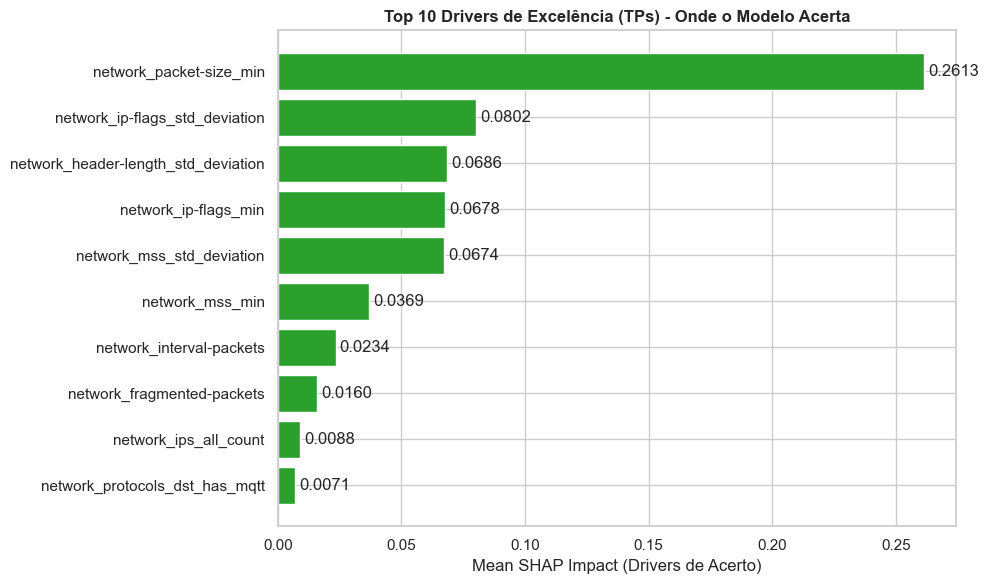

In [131]:
# --- RANKING DE SUPER-DRIVERS DE ACERTO (TPs) ---
TP_DIR = XAI_DIR / "tp_importance" / "per_class"

all_tp_drivers = []
for tp_file in TP_DIR.glob("*.csv"):
    df = pd.read_csv(tp_file)
    # Extrai o nome da classe do arquivo (ajuste o split se necessário)
    # Exemplo de nome: tp_random_forest_multi_class_benign.csv
    cls_name = tp_file.stem.split("_class_")[-1]
    
    df["Classe_Relacionada"] = cls_name
    all_tp_drivers.append(df[~df["feature"].str.contains("device|label", case=False)])

df_all_tp = pd.concat(all_tp_drivers, ignore_index=True)

# Agrupa por feature para ver quais são os pilares de acerto globais
df_tp_ranking = df_all_tp.groupby("feature")[["importance"]].mean().sort_values("importance", ascending=False).reset_index()

def get_best_classes_for_tp(feature):
    return ", ".join(df_all_tp[df_all_tp["feature"] == feature].sort_values("importance", ascending=False).head(3)["Classe_Relacionada"].unique())

print("\n[RANKING DOS DRIVERS DE EXCELÊNCIA (TPs) - GLOBAL]")
df_tp_ranking["Classes_Mais_Beneficiadas"] = df_tp_ranking["feature"].apply(get_best_classes_for_tp)
display(df_tp_ranking.head(10))

# Plot do Ranking
fig, ax = plt.subplots(figsize=(10, 6))
df_top_tp = df_tp_ranking.head(10)
ax.barh(df_top_tp["feature"].iloc[::-1], df_top_tp["importance"].iloc[::-1], color="#2ca02c")
ax.set_title("Top 10 Drivers de Excelência (TPs) - Onde o Modelo Acerta", fontweight="bold")
ax.set_xlabel("Mean SHAP Impact (Drivers de Acerto)")
ax.bar_label(ax.containers[0], fmt='%.4f', padding=3)
plt.tight_layout()
plt.show()